Name: Emily Savoie

Labpartner(s: Maya Maes-Johnson

In [1]:
#import statements go here
import matplotlib.pyplot as plt
import numpy as np

# Class 6.1

Today we will start with fiunction sharing and do more matplotlib.

# Warmups 6.1

**W.1** Write a function that loops through a list of numbers and checks if they are odd or even, then returns a new list of "odd" or "even" for each element in the input list. For example:

Given the list [3,8,7] the function would return
["odd", "even", "odd"]

In [ ]:
def evenodd (*ls):
    new_ls = []
    for x in ls:
        if x % 2 == 0:
          new_ls.append('even')
        else:
           new_ls.append('odd')

    return(new_ls)

In [19]:
evenodd(3,6,8,9,22,32,37,67)

['odd', 'even', 'even', 'odd', 'even', 'even', 'odd', 'odd']

# Lecture 6.1

### Agenda:

- Show us your functions
- Questions
- xarray package and plotting netcdf files


### Show us your functions (from Lab 5.2) - first 4 people today, the rest on Wed

### Questions

### Loading and plotting netcdf files using xarray

Most modeling data output is in the form of netcdf files, as they can store more data (in binary) using less memory. Netcdf files are great because they tell you all about what is in the file (the variables and their units) with their metadata, which is kind of like the docstring we made for our function. There are a number of command line (unix-based) utilities for dealing with netcdf files, which I am not planning to cover in this course (though I use these all the time). Hit me up if you want some tutorials on this, or if enough of you are keen I will put some unix tutorials in the schedule.

Xarray is a python package that does analysis and basic plotting of netcdf files. This is actively being developed by folks like the pangeo consortium (https://pangeo.io), which is creating a number of python utilities for big data geoscience, like dealing with massive amounts of climate model output. There are other packages that can be used for parsing netcdf files, but they are cumbersome and clunky. Trust me, xarray is the best thing since sliced bread for big data geoscience. 

Let's grab some data and start playing with it. We are going to use the HYCOM Gulf of Mexico Analysis output, which is basically weather prediction for our local ocean made by the Navy, freely available. https://www.hycom.org.

In [2]:
import xarray as xr
# make sure you also have nectdf4 installed!

### Part 1: Load in the file (always the hardest part)!

We want the HYCOM GoM reanalysis product: https://www.hycom.org/dataserver/gom/gom-reanalysis
And we are going to use the coarser resolution (1/25 degree) version for computational speed, the "HYCOM-TSIS 1/25º Gulf of Mexico Reanalysis (GOMe0.04)" version, which goes from 2024-09-01 to present.

There are two ways to get this data, we can click around and download it, or we can use the opendap link (see http://xarray.pydata.org/en/stable/io.html).

In [3]:
# here I am going to grab the hindcast they made for Jan 1 2026. 

#First let's navigate to the website and download the 2d file.

# Note I can use the download the file I got by clicking on the https server link and putting the correct path to load in:
file_path= "039_archv.2026_001_00_2d.nc" # you will have to change this for your computer

# now upload from the file I downloaded manually:
hycom_data = xr.open_dataset(file_path, decode_times=False)

# honestly I don't know why you need the decode_times bit with open_dataset

# I just know it doesn't work most of the time if you leave it out (kudos for anyone who figures it out!)

In [6]:
hycom_data

<xarray.Dataset> Size: 5MB
Dimensions:                (MT: 1, Latitude: 385, Longitude: 525)
Coordinates:
  * MT                     (MT) float64 8B 4.566e+04
    Date                   (MT) float64 8B ...
  * Latitude               (Latitude) float32 2kB 18.09 18.13 ... 31.93 31.96
  * Longitude              (Longitude) float32 2kB -98.0 -97.96 ... -77.04
Data variables:
    surface_e_stress       (MT, Latitude, Longitude) float32 808kB ...
    surface_n_stress       (MT, Latitude, Longitude) float32 808kB ...
    ssh                    (MT, Latitude, Longitude) float32 808kB ...
    u_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    v_barotropic_velocity  (MT, Latitude, Longitude) float32 808kB ...
    mixed_layer_thickness  (MT, Latitude, Longitude) float32 808kB ...
Attributes:
    Conventions:  CF-1.6
    title:        HYCOM
    source:       HYCOM archive file
    experiment:   01.4
    history:      archv2ncdf2d
    comment:      p-grid

The result is an xarray dataset, which is similar to the pandas dataframes you have been using. It has dimensions, coordinates and variables. The first thing to do when you get a dataset is to figure out what is in it and explore it a bit.

In [7]:
# what is the lat spacing and domain?

hycom_data.Latitude

# looks like it goes from 18.09 N to 31.96 N and the spacing is 0.04 degrees, i.e. 1/25, so that checks
# 1 degree is about 100 km, so thats 4 km model resolution

<xarray.DataArray 'Latitude' (Latitude: 385)> Size: 2kB
array([18.091648, 18.129667, 18.167677, ..., 31.892748, 31.926704, 31.960648],
      shape=(385,), dtype=float32)
Coordinates:
  * Latitude  (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
Attributes:
    standard_name:  latitude
    units:          degrees_north
    axis:           Y

In [8]:
hycom_data.Longitude

<xarray.DataArray 'Longitude' (Longitude: 525)> Size: 2kB
array([-98.      , -97.96002 , -97.91998 , ..., -77.119995, -77.08002 ,
       -77.03998 ], shape=(525,), dtype=float32)
Coordinates:
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  longitude
    units:          degrees_east
    point_spacing:  even
    axis:           X

In [9]:
hycom_data.ssh

<xarray.DataArray 'ssh' (MT: 1, Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.566e+04
    Date       (MT) float64 8B ...
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    standard_name:  sea_surface_elevation
    units:          m
    valid_range:    [-0.504511   0.7986358]
    long_name:       sea surf. height  [01.4H]

We will plot this in the next section

In [ ]:
# alternatley, with a little help from ChatGPT I can make a nice workflow to get the file from the opendap (thredds) server

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_01_2d.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data2 = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data2

# note, this would make a great function

However, what I really want is to plot SST, so I need a file with temperature, let's check out the other file type

In [4]:
# modify the file to get the 3D output file

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2026/"
    "039_archv.2026_001_00_3z.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data_3D = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data_3D

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2026/039_archv.2026_001_00_3z.nc


<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.566e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf3z
    DODS_EXTRA.Unlimited_Dimension:  MT

### Part2: Basic plotting with xarray (not publication ready!)

Note that one of the amazing things about xarray, is that it actually does not go and get the data until you call for it, so this will take a minute to upload.

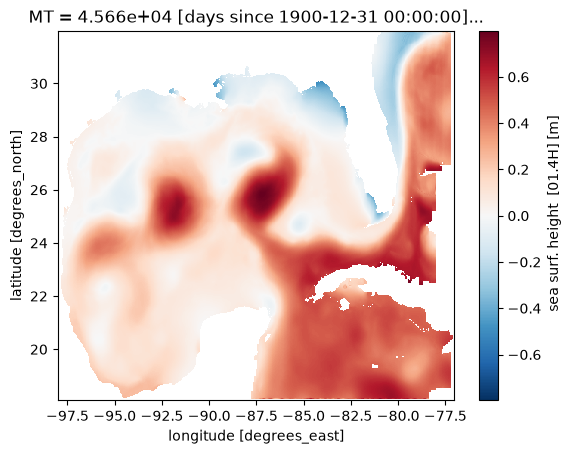

In [11]:
hycom_data.ssh.plot()

Note that xarray, like pandas, uses matplotlib for plotting, and that it figured out to use the blue to red colormap based on the type of data. Pretty cool. 

Let's plot some temperature data and see how it compares. Since temperature data is given for the whole depth, we have to select a level.

water_temp
(MT, Depth, Latitude, Longitude)

In [13]:
hycom_data_3D.water_temp

<xarray.DataArray 'water_temp' (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)> Size: 32MB
[8085000 values with dtype=float32]
Coordinates:
  * MT         (MT) float64 8B 4.566e+04
    Date       (MT) float64 8B ...
  * Depth      (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3240066 28.546928 ]
    _ChunkSizes:    [  1  14 193 263]

In [5]:
hycom_data_3D.get_index('Depth')

Index([   0.0,    2.0,    4.0,    6.0,    8.0,   10.0,   12.0,   15.0,   20.0,
         25.0,   30.0,   35.0,   40.0,   45.0,   50.0,   60.0,   70.0,   80.0,
         90.0,  100.0,  125.0,  150.0,  200.0,  250.0,  300.0,  350.0,  400.0,
        500.0,  600.0,  700.0,  800.0,  900.0, 1000.0, 1250.0, 1500.0, 2000.0,
       2500.0, 3000.0, 4000.0, 5000.0],
      dtype='float32', name='Depth')

In [33]:
hycom_data_3D.get_index('Depth').get_loc(100.0)

19

In [12]:
hycom_data_3D.water_temp[0,0,:,:]

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3240066 28.546928 ]
    _ChunkSizes:    [  1  14 193 263]

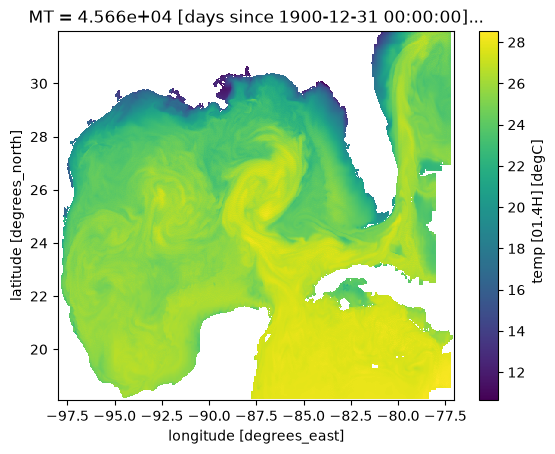

In [14]:
hycom_data_3D.water_temp[0,0,:,:].plot()

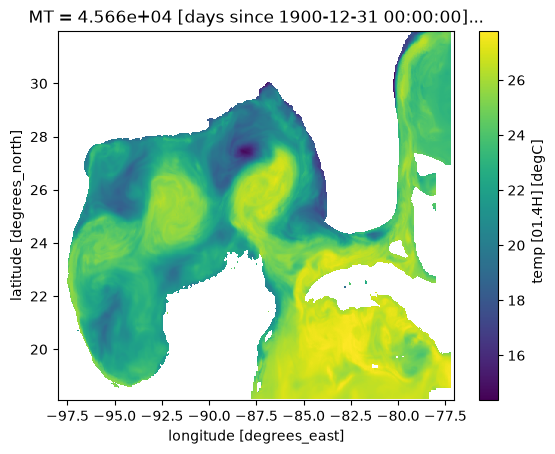

In [15]:
hycom_data_3D.water_temp[0,19,:,:].plot()

Those plots are really small. I like to change the default matplotlib preferences to make my plots bigger.

In [6]:
# change all the defaults (usually I stick this up with the import statements)

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [8.0, 5.0]
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['savefig.dpi'] = 500

mpl.rcParams['font.size'] = 12
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['figure.titlesize'] = 'medium'
mpl.rcParams['lines.linewidth']= 2.0

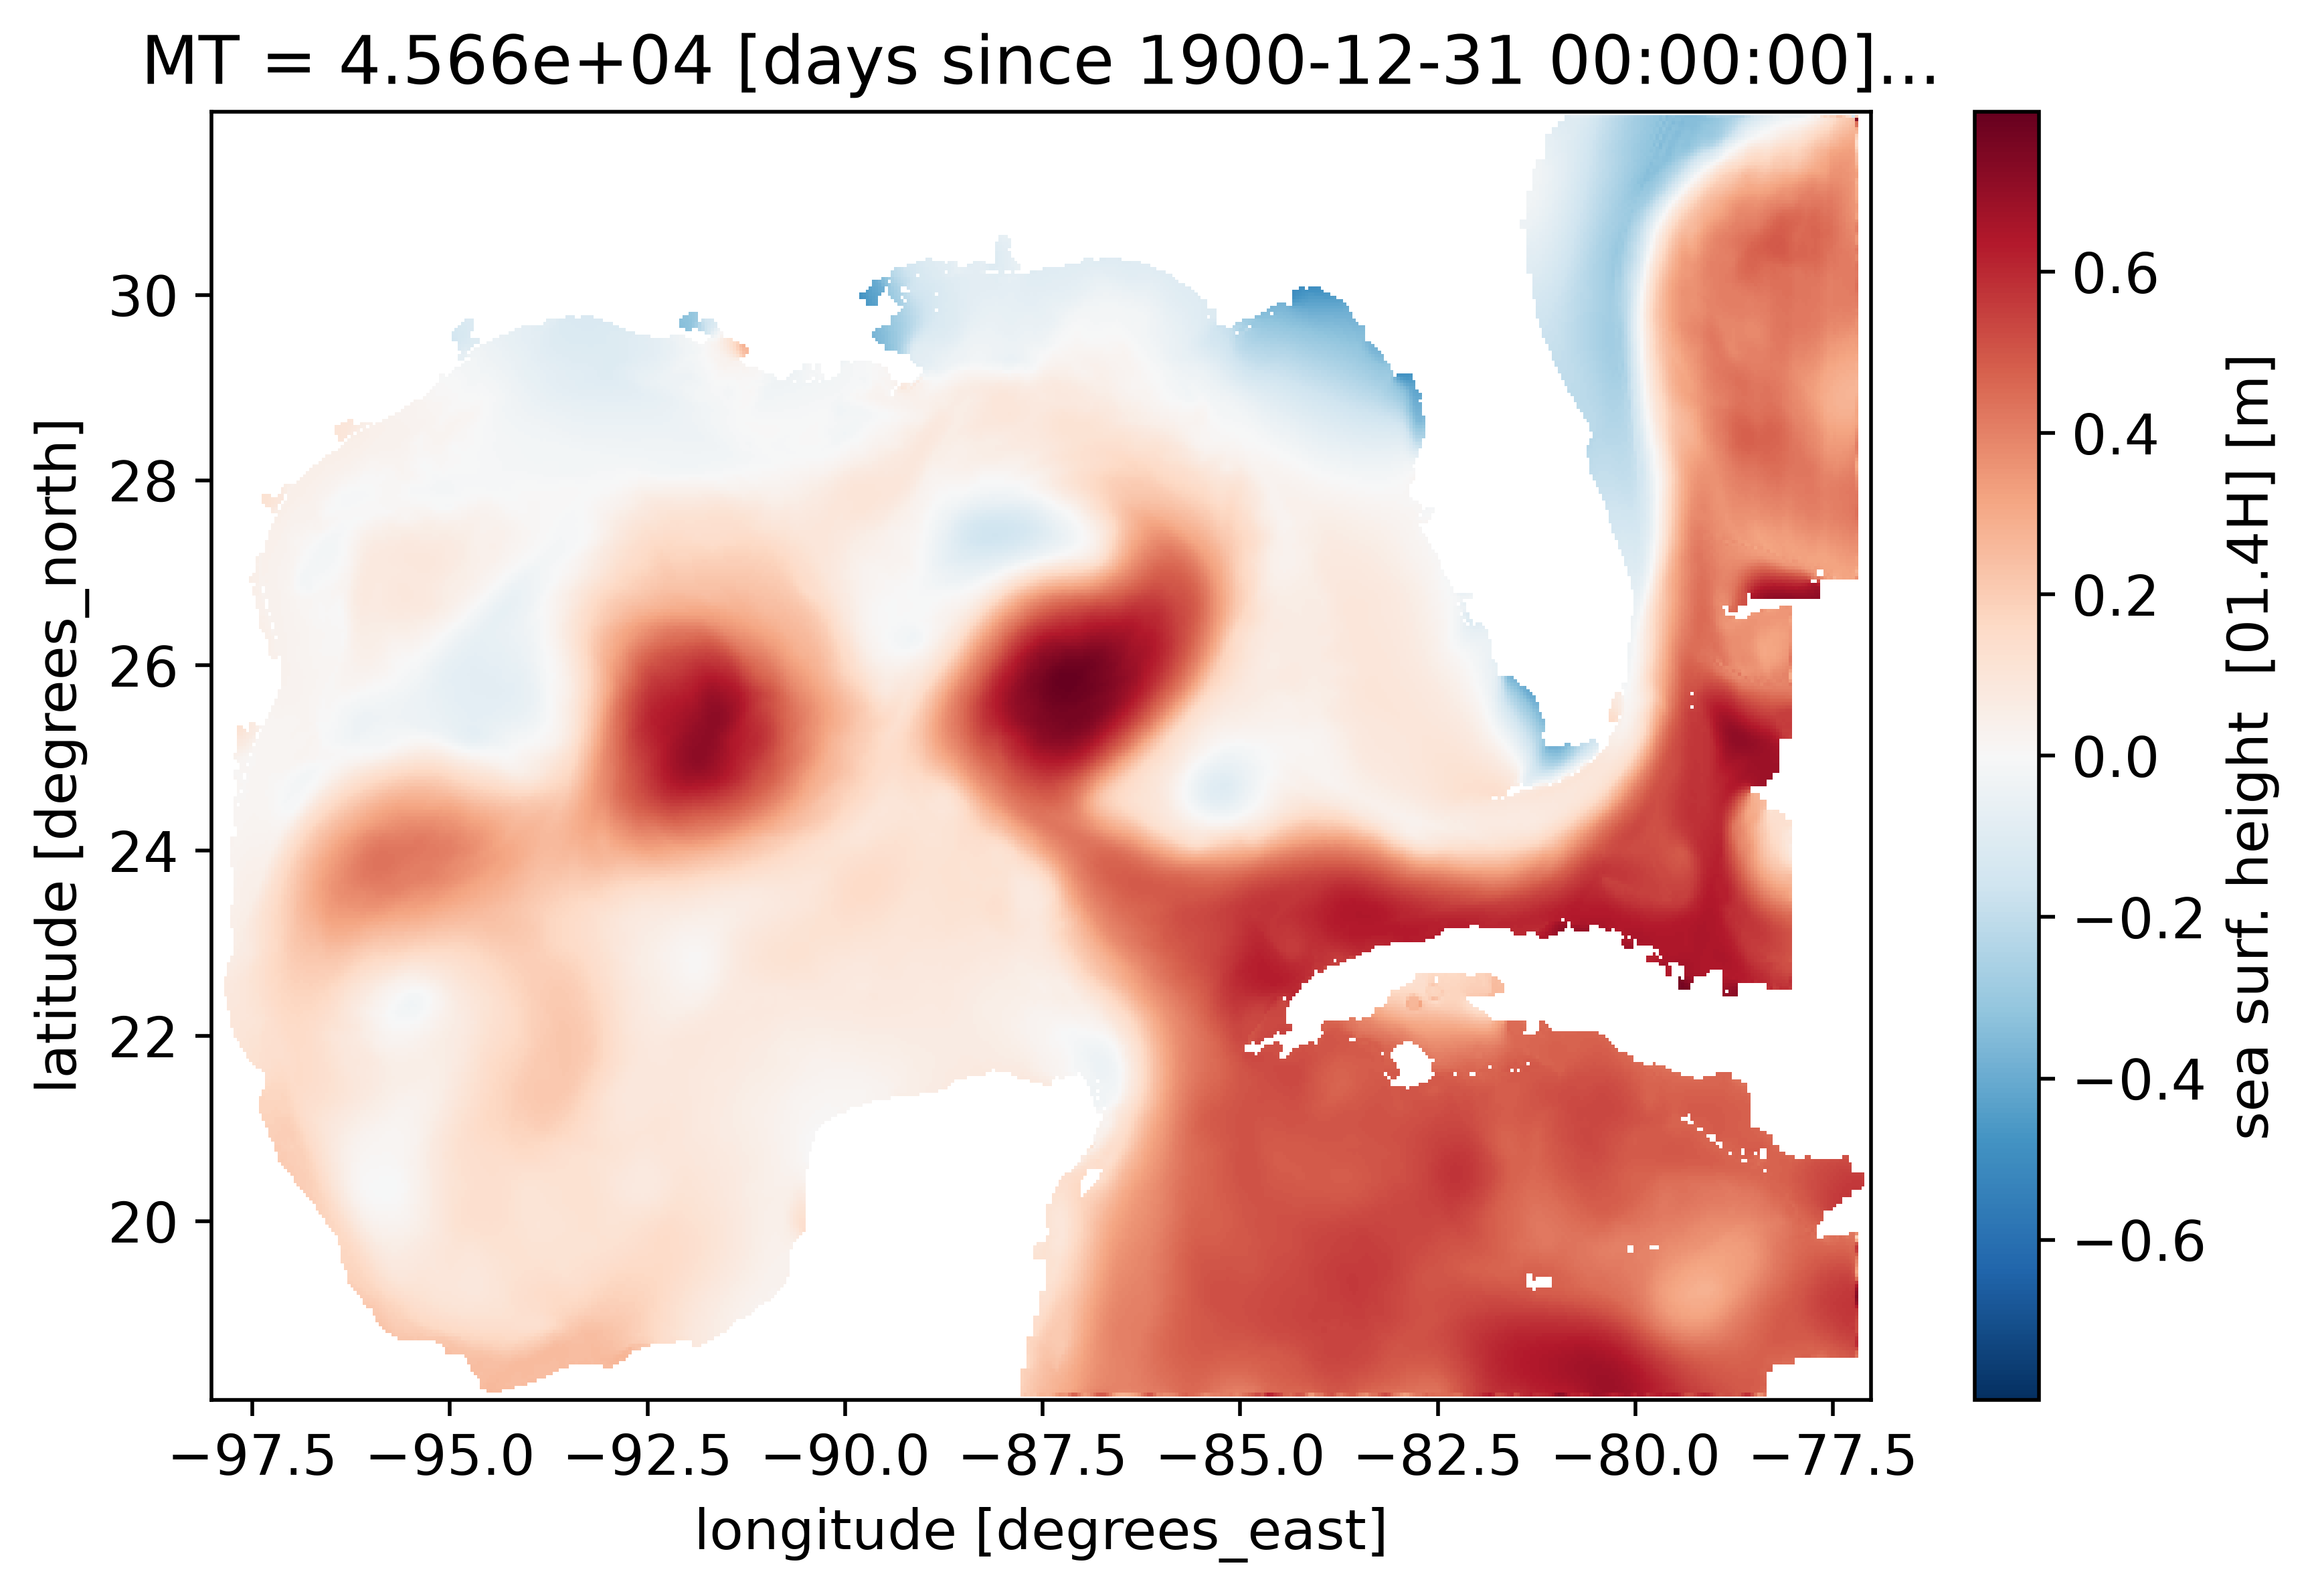

In [17]:
# now it's big and pretty.

hycom_data.ssh.plot()

Note if you know you are going to plot the same bit of data over and over again to fiddle with the plot, you can download the data you need and save it in an array to make the proccess faster.

In [18]:
SST = hycom_data_3D.water_temp[0,0,:,:]

In [19]:
type(SST)

xarray.core.dataarray.DataArray

In [20]:
SST # note it saves all the coordinates I need.

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.566e+04
    Date       float64 8B ...
    Depth      float32 4B 0.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.3240066 28.546928 ]
    _ChunkSizes:    [  1  14 193 263]

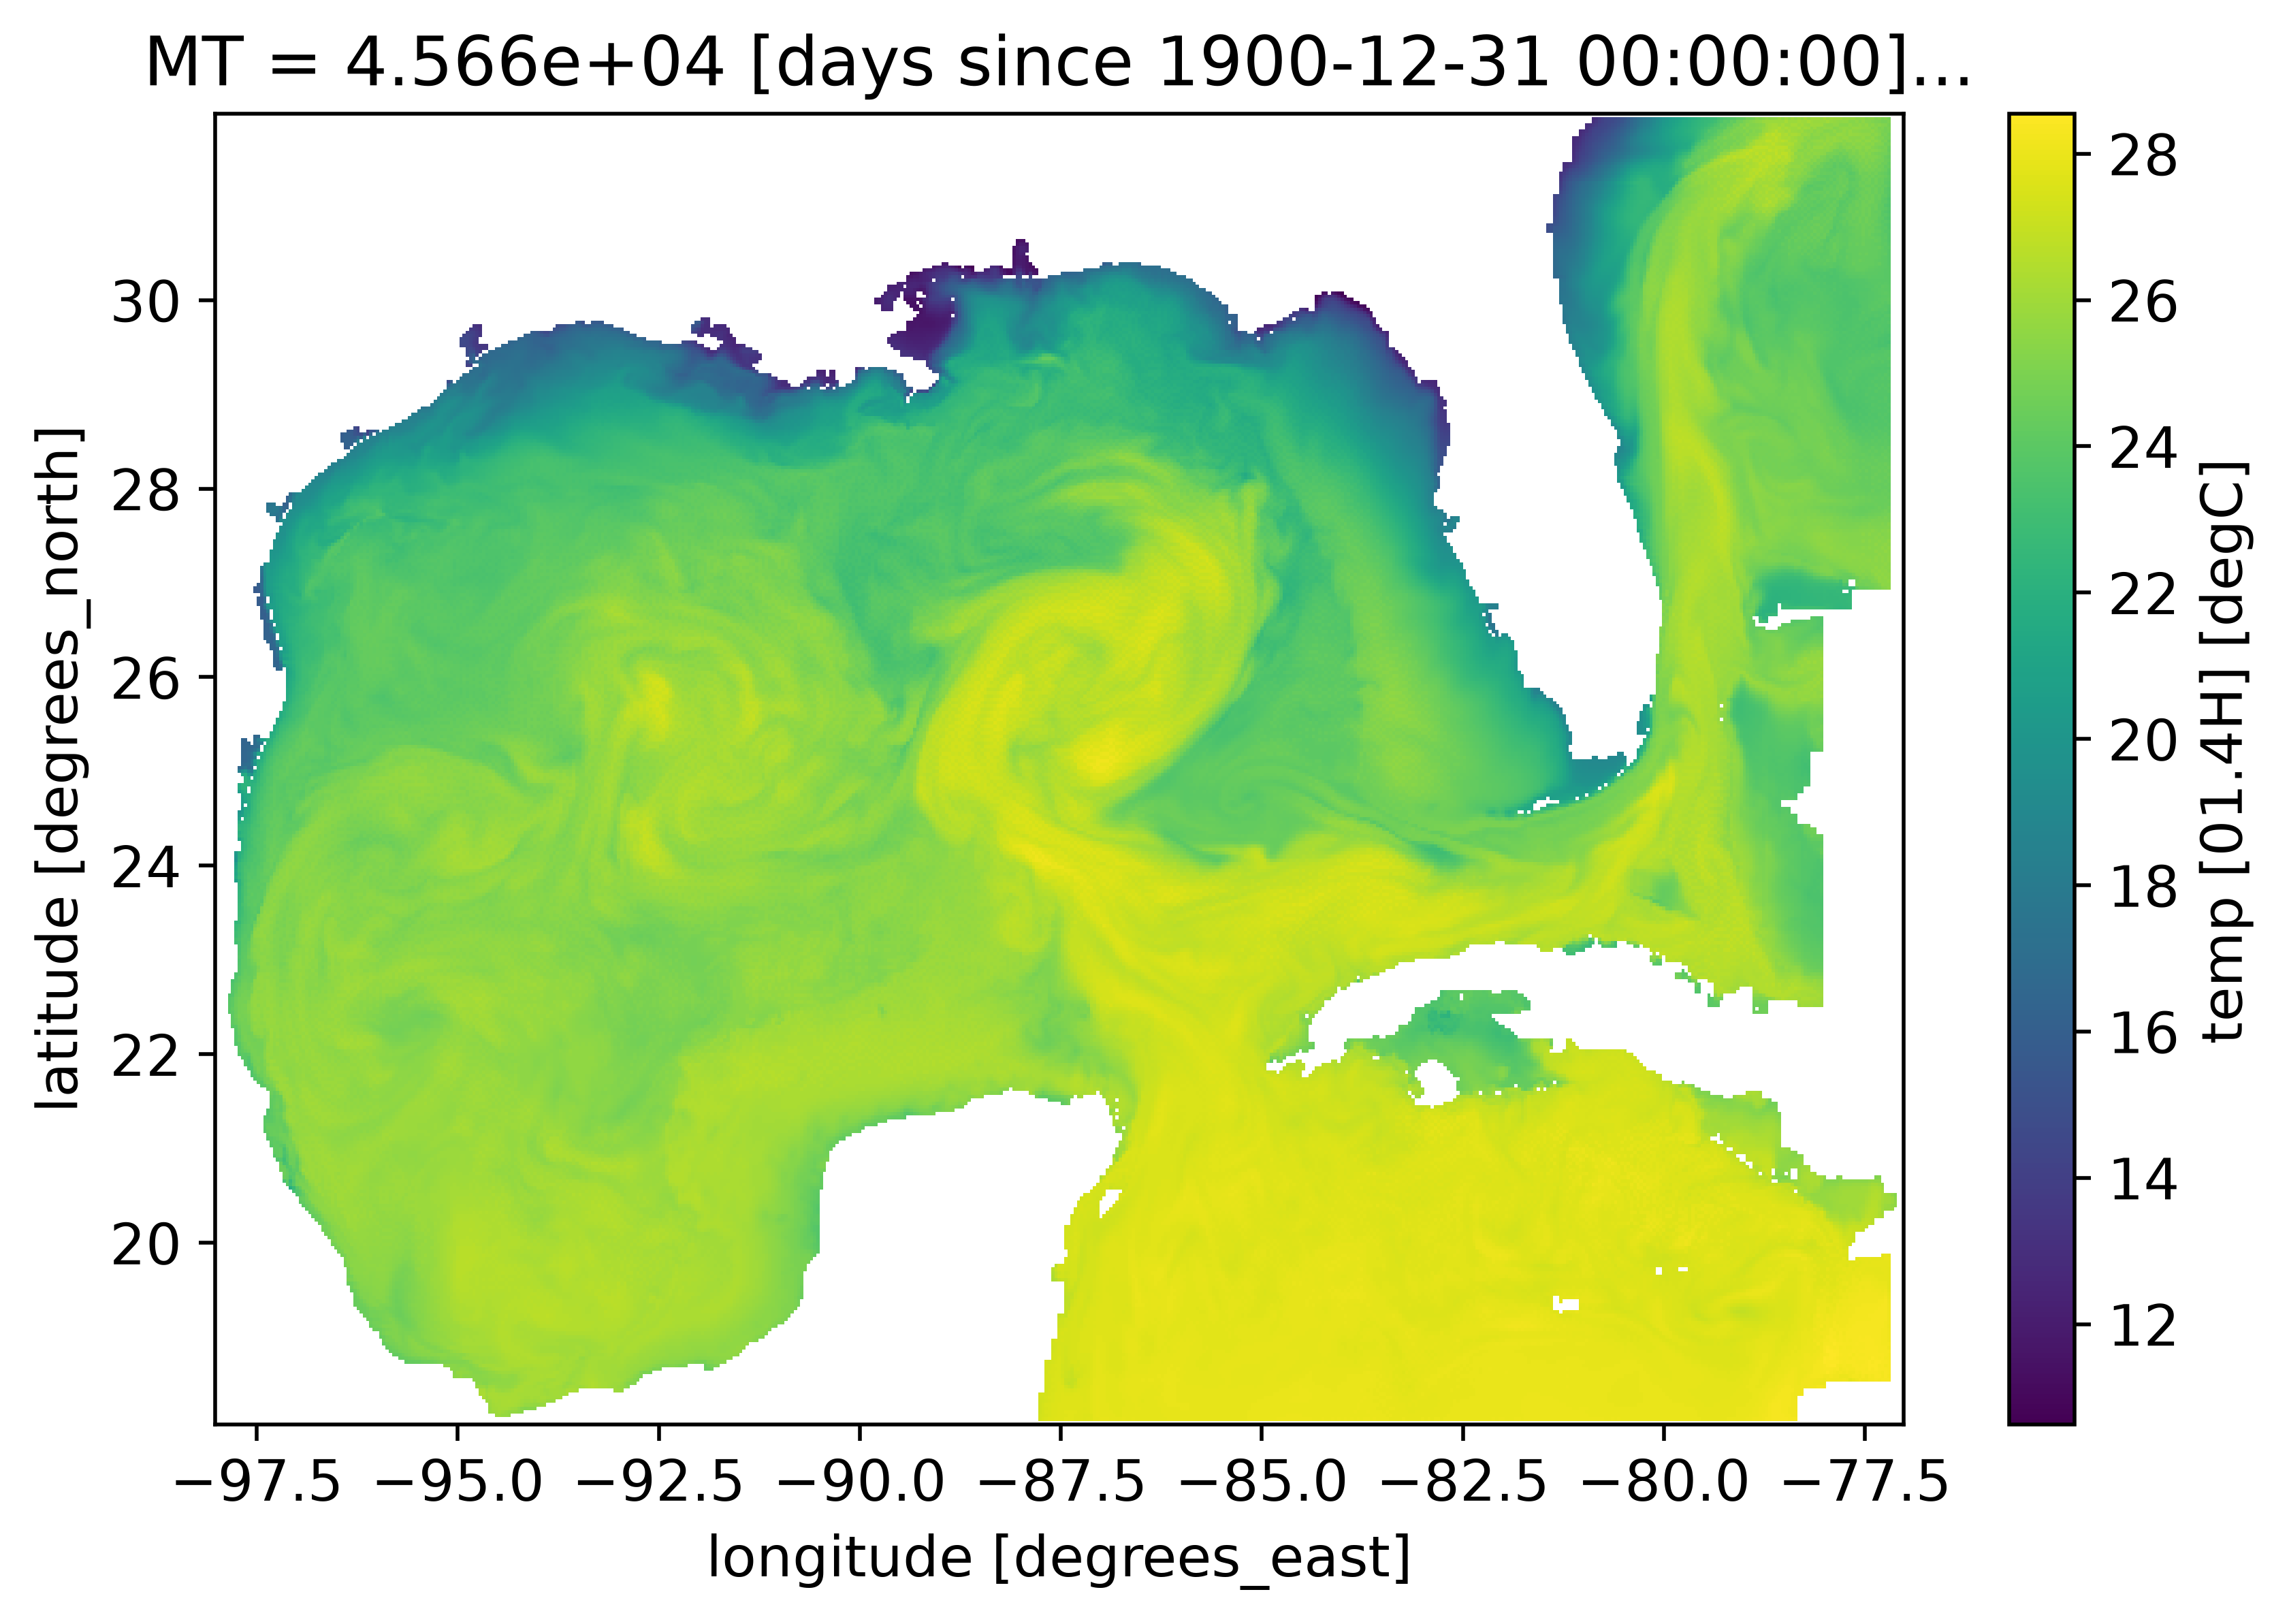

In [21]:
SST.plot()

I can also save this subset of the data to a new netcdf file locally very easily. See http://xarray.pydata.org/en/stable/io.html for more details.

In [22]:
SST.to_netcdf('SST_2001_001_00.nc') # the new netcdf file is saved in the local directory

And then I load in the new netcdf file in the same way as I did the remote data, but using the local filepath

In [23]:
sst_data = xr.open_dataset('SST_2001_001_00.nc', decode_times=False)

In [24]:
sst_data

<xarray.Dataset> Size: 812kB
Dimensions:     (Latitude: 385, Longitude: 525)
Coordinates:
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT          float64 8B ...
    Date        float64 8B ...
    Depth       float32 4B ...
Data variables:
    water_temp  (Latitude, Longitude) float32 808kB ...

# Lab 6.1

**E.0** Finish Lab 5.2 if you haven't already.

**E.1** Complete Introduction to Data Visualization with Matplotlib Chapters 1-2. Let me know if this feels like a good pace

**E.2** Make notes for yourself on progamming tecniques and commands you learned in the lecture and datacamp chapter above, including examples, comments and explainitory text. You can do this here or in a separate notebook that you link to here. Basically, you are making a cheat sheet for yourself.

See also http://xarray.pydata.org/en/stable/plotting.html for more info about plotting right from xarray (optional).

matplotlib.pyplot conventionally called using plt. 
When calling plt.subplots, two objects are created, a figure and an axes object. The figure object is the container to hold everything seen. The axes object holds the data to be put shown on the figure. To add data to figure, you use plotting commands as methods of the axes object. You can call the .plot method multiple times to plot different data on the same figure. 

Customization of within plot elements are arguments within the .plot call.
Axis and tick customization uses different methods. 

In [ ]:
# Syntax for plt.subplots
fig, ax = plt.subplots()
ax.plot(...)
plt.show()

In [ ]:
# Plot customization syntax
ax.plot(x, y,
        # Changes style of points. Can use 'v', '*', '<', etc. Check documentation for list
        marker = 'o',
        # Changes line type. Can use '-','.',-.', etc. View documentation for list.
        linestyle = '--',
        # Change color. View documentation for comprehensive list of recognized colors.
        color = 'r') 

In [ ]:
# Label customizaation syntax
# Can change the color of labels
ax.set_xlabel('text', color = 'pink')
ax.set_ylabel('text')
ax.set_title('text')

# To change tick mark appearance use tick_params
# labelsize changes font size of tick labels
# axis can be x, y, or both
ax.tick_params(axis, color = 'red', labelsize = 10)

# Can customize tick marks using below syntax
# Can change the angle of tick labels using rotation argument
ax.set_xticklabels('text', rotation = 90)
ax.set_yticklabels('text; can call variable from data for labels')

In [ ]:
# To make multi-panel plots provide numbers in the .subplots call that specify rows and columns
# To make panels share an axis can add sharex = True or sharey = True to subplots.
fig, ax = plt.subplots(nrows, ncols)

# To specify the plot to edit when dealing with multiple panels, use indexing with plot call
ax[rindex, cindex].plot(...)

In [ ]:
# Syntax for plotting two different variables on the same panel 
fig, ax = plot.subplots()
ax.plot(...)
# Sets the x axis to be the same for the second variable added
ax2 = twinx()
ax2.plot(...)

In [ ]:
# Syntax for adding annotation to plots
ax.annotate('text', 
            # xy sets the point to use for annotation
            xy = (x pos, y pos),
            # xytext sets text position if need to offset from point of annotation
            xytext = (x pos, y pos),
            # arrowprops inserts arrow from text to point for annotation
            # Dictionary syntax for arrow customizations
            arrowprops = {'arrowstyle':'->','color':'gray'})

Matplotlib has many different graph types that can be called. Using plot() will default to lines. Below are some other graph type calls:  
* .bar() = bar chart
* .hist() = histogram
* .scatter() = scatter plot

In [ ]:
# To make stacked bar plots use below syntax
fig, ax = plt.subplots()
# First bar call
# Can add label to calls to help with readability
ax.bar(x, y1, label = 'text')
# Add stacked bar. bottom indicates that the bottom of y2 should be at the height of y1
ax.bar(x, y2, bottom = y1)
# Can add on to bottom argument to add stacks
ax.bar(x, y3, bottom = y1 + y2)

# Adds the legend to the plot
ax.legend()

In [ ]:
# Syntax for histograms
fig, ax = plt.subplots()
# the y axis of a histogram is the # of observations within histogram bins
# Like the bar chart, a label argument within the plotting call will determine a legend if called
ax.hist(x, label = 'text')

# Default bin size for histogram is 10
# To customize bin size, use 'bins' argument
# Using an integer for 'bins' will make that many bins 
ax.hist(x, label = 'text', bins = 15)
# Using a seq. of numbers will assign the numbers as the boundaries between bins
ax.hist(x, label = 'text', bins = [150, 160, 170])

# To adjust the type of histogram, use 'histtype' argument
# Default type is solid bars
ax.hist(x, histtype = 'step')

In [ ]:
# To change color of scatter plot points use 'c'
ax.scatter(x = var1, y = var2, c = var3)

Matplotlib allows for statistical plotting by adding errors or creating box plots. Different plot methods may have slightly different syntax for addition of error bars.

In [ ]:
# To add error bars to bar charts use 'yerr' argument and the .std() method of the variable being plotted
ax.bar(xlabel, y, yerr = y.std())

# To add error bars to a line graph use .errorbar() method
ax.errorbar(x, y, yerr = y.std)

In [ ]:
# To make boxplots use the below syntax
fig, ax = plt.subplots()
ax.boxplot([x1, x2])
# Set x tick labels separate
ax.set_xticklabels('text')

# Boxplots show medians as lines inside box, the box edges show 25th and 75th 
# percentiles, whiskers show 1.5x size of inter-quartile range beyond percentiles. 
# Points outside of whiskers are considered outliers, assuming normal distribution

You can change overall stype of matplotlib plots using plt.style.use(). See documentation for available styles. 
Things to keep in mind about style:  
* Dark backgrounds are usually less visible and discouraged without good reason
* Colors matter. Keep in mind colorblind-friendly, grayscale, contrast. 

In [ ]:
# To emulate ggplot2 
plt.style.use('ggplot')

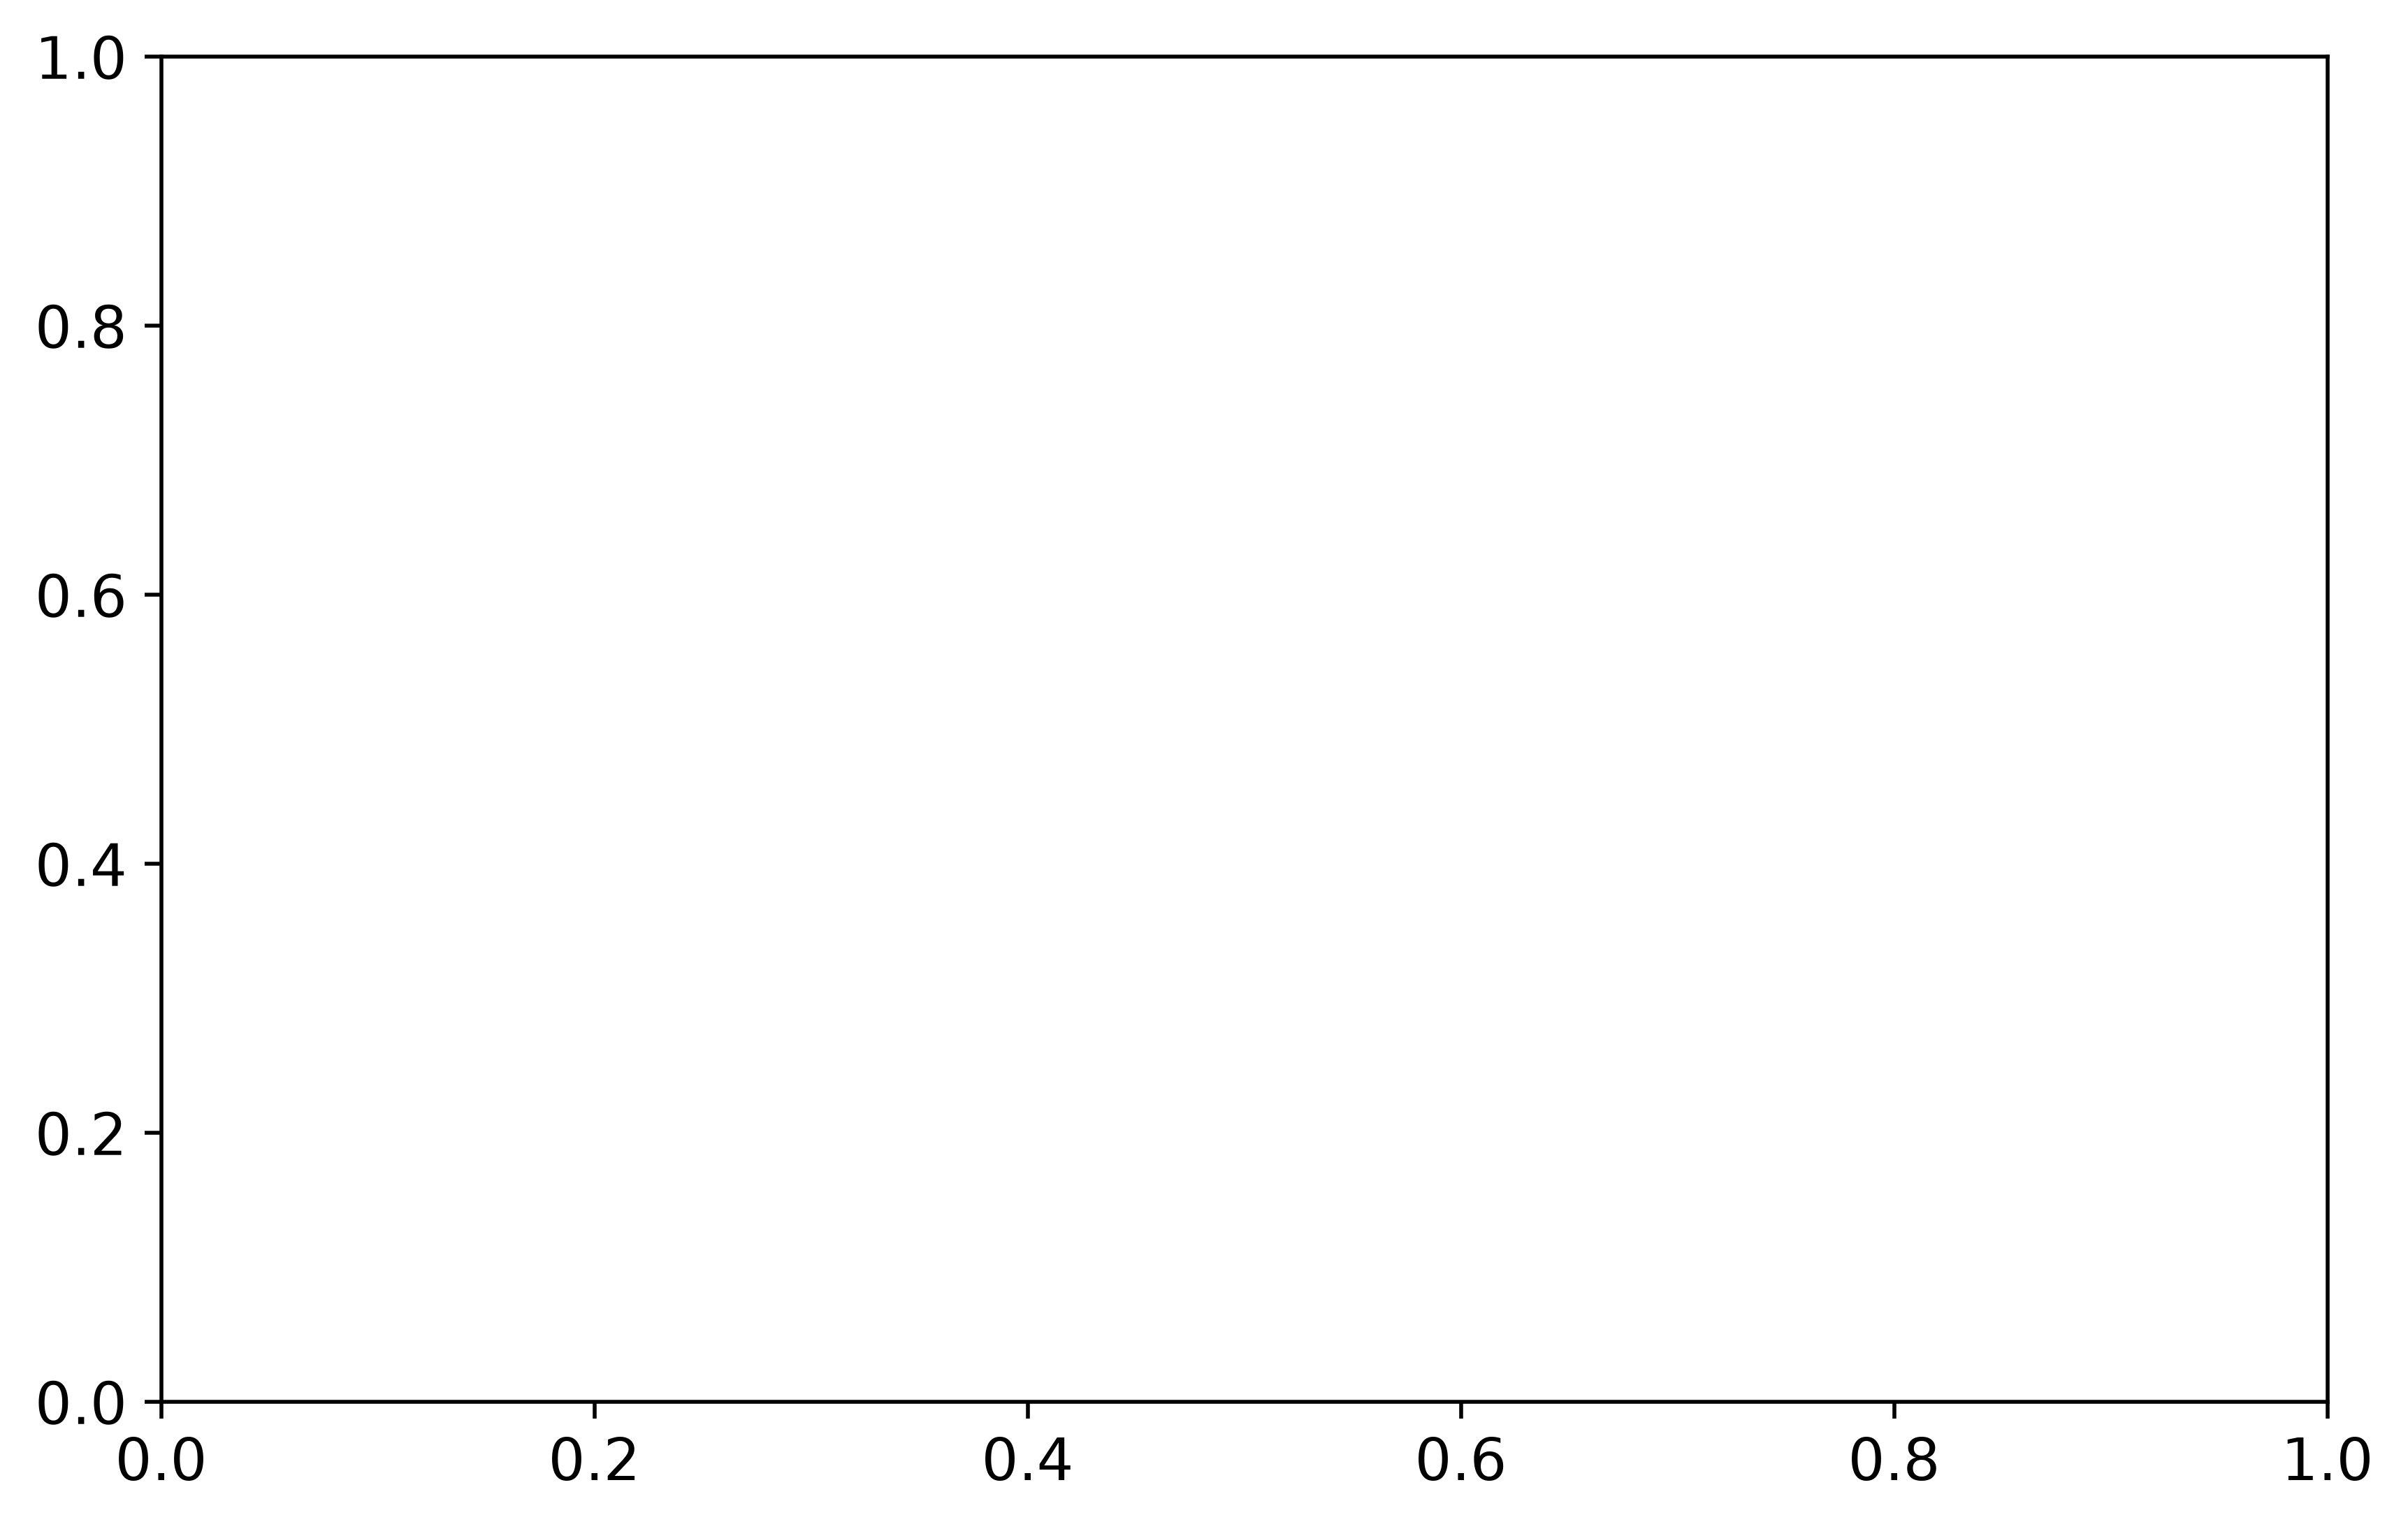

In [ ]:
# Saving figure syntax
fig.savefig('filename.format')
# You can save figure as png, jpg, pdf, etc
# To change quality of saved png use 'dpi'
fig.savefig('filename', dpi = 300)

In [ ]:
# To control size of figure use set_size_inches
fig.set_size_inches([width, height])

**E.3** Using the lecture as a guide, save the sea surface temperature at ~100 m depth on your birthday in 2025 as a new, local netcdf file. You don't have to submit the file, just the code here.

In [ ]:
# My birthday is Oct. 16th. This is the 289th day of the year. The HYCOM data file is from noon on that day in 2025. 

# Paste the URL copied from the HYCOM data website
file_url = (
    "https://data.hycom.org/datasets/GOMe0.04/expt_03.9/data/archive/2025/"
    "039_archv.2025_289_12_3z.nc"
)

# Convert the download URL to an OPeNDAP URL
opendap_url = file_url.replace(
    "https://data.hycom.org/",
    "https://tds.hycom.org/thredds/dodsC/"
)

print(opendap_url)

# Open the remote NetCDF dataset
hycom_data_3D = xr.open_dataset(
    opendap_url,
    engine="netcdf4",
    decode_times=False
)

hycom_data_3D

https://tds.hycom.org/thredds/dodsC/datasets/GOMe0.04/expt_03.9/data/archive/2025/039_archv.2025_289_12_3z.nc


<xarray.Dataset> Size: 162MB
Dimensions:     (MT: 1, Depth: 40, Latitude: 385, Longitude: 525)
Coordinates:
  * MT          (MT) float64 8B 4.558e+04
    Date        (MT) float64 8B ...
  * Depth       (Depth) float32 160B 0.0 2.0 4.0 6.0 ... 3e+03 4e+03 5e+03
  * Latitude    (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude   (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
Data variables:
    u           (MT, Depth, Latitude, Longitude) float32 32MB ...
    v           (MT, Depth, Latitude, Longitude) float32 32MB ...
    w_velocity  (MT, Depth, Latitude, Longitude) float32 32MB ...
    water_temp  (MT, Depth, Latitude, Longitude) float32 32MB ...
    salinity    (MT, Depth, Latitude, Longitude) float32 32MB ...
Attributes:
    Conventions:                     CF-1.0
    title:                           HYCOM
    source:                          HYCOM archive file
    experiment:                      01.4
    history:                         archv2ncdf3z
    DODS_EXTRA.Unlimited_Dimension:  MT

**E.4** Plot the above (your 2025 birthday SST) using the basic xarray funcitons

In [10]:
# To confirm the index value for 100 m depth
hycom_data_3D.get_index('Depth').get_loc(100.0)

19

Text(0, 0.5, 'Latitude($^\\circ$N)')

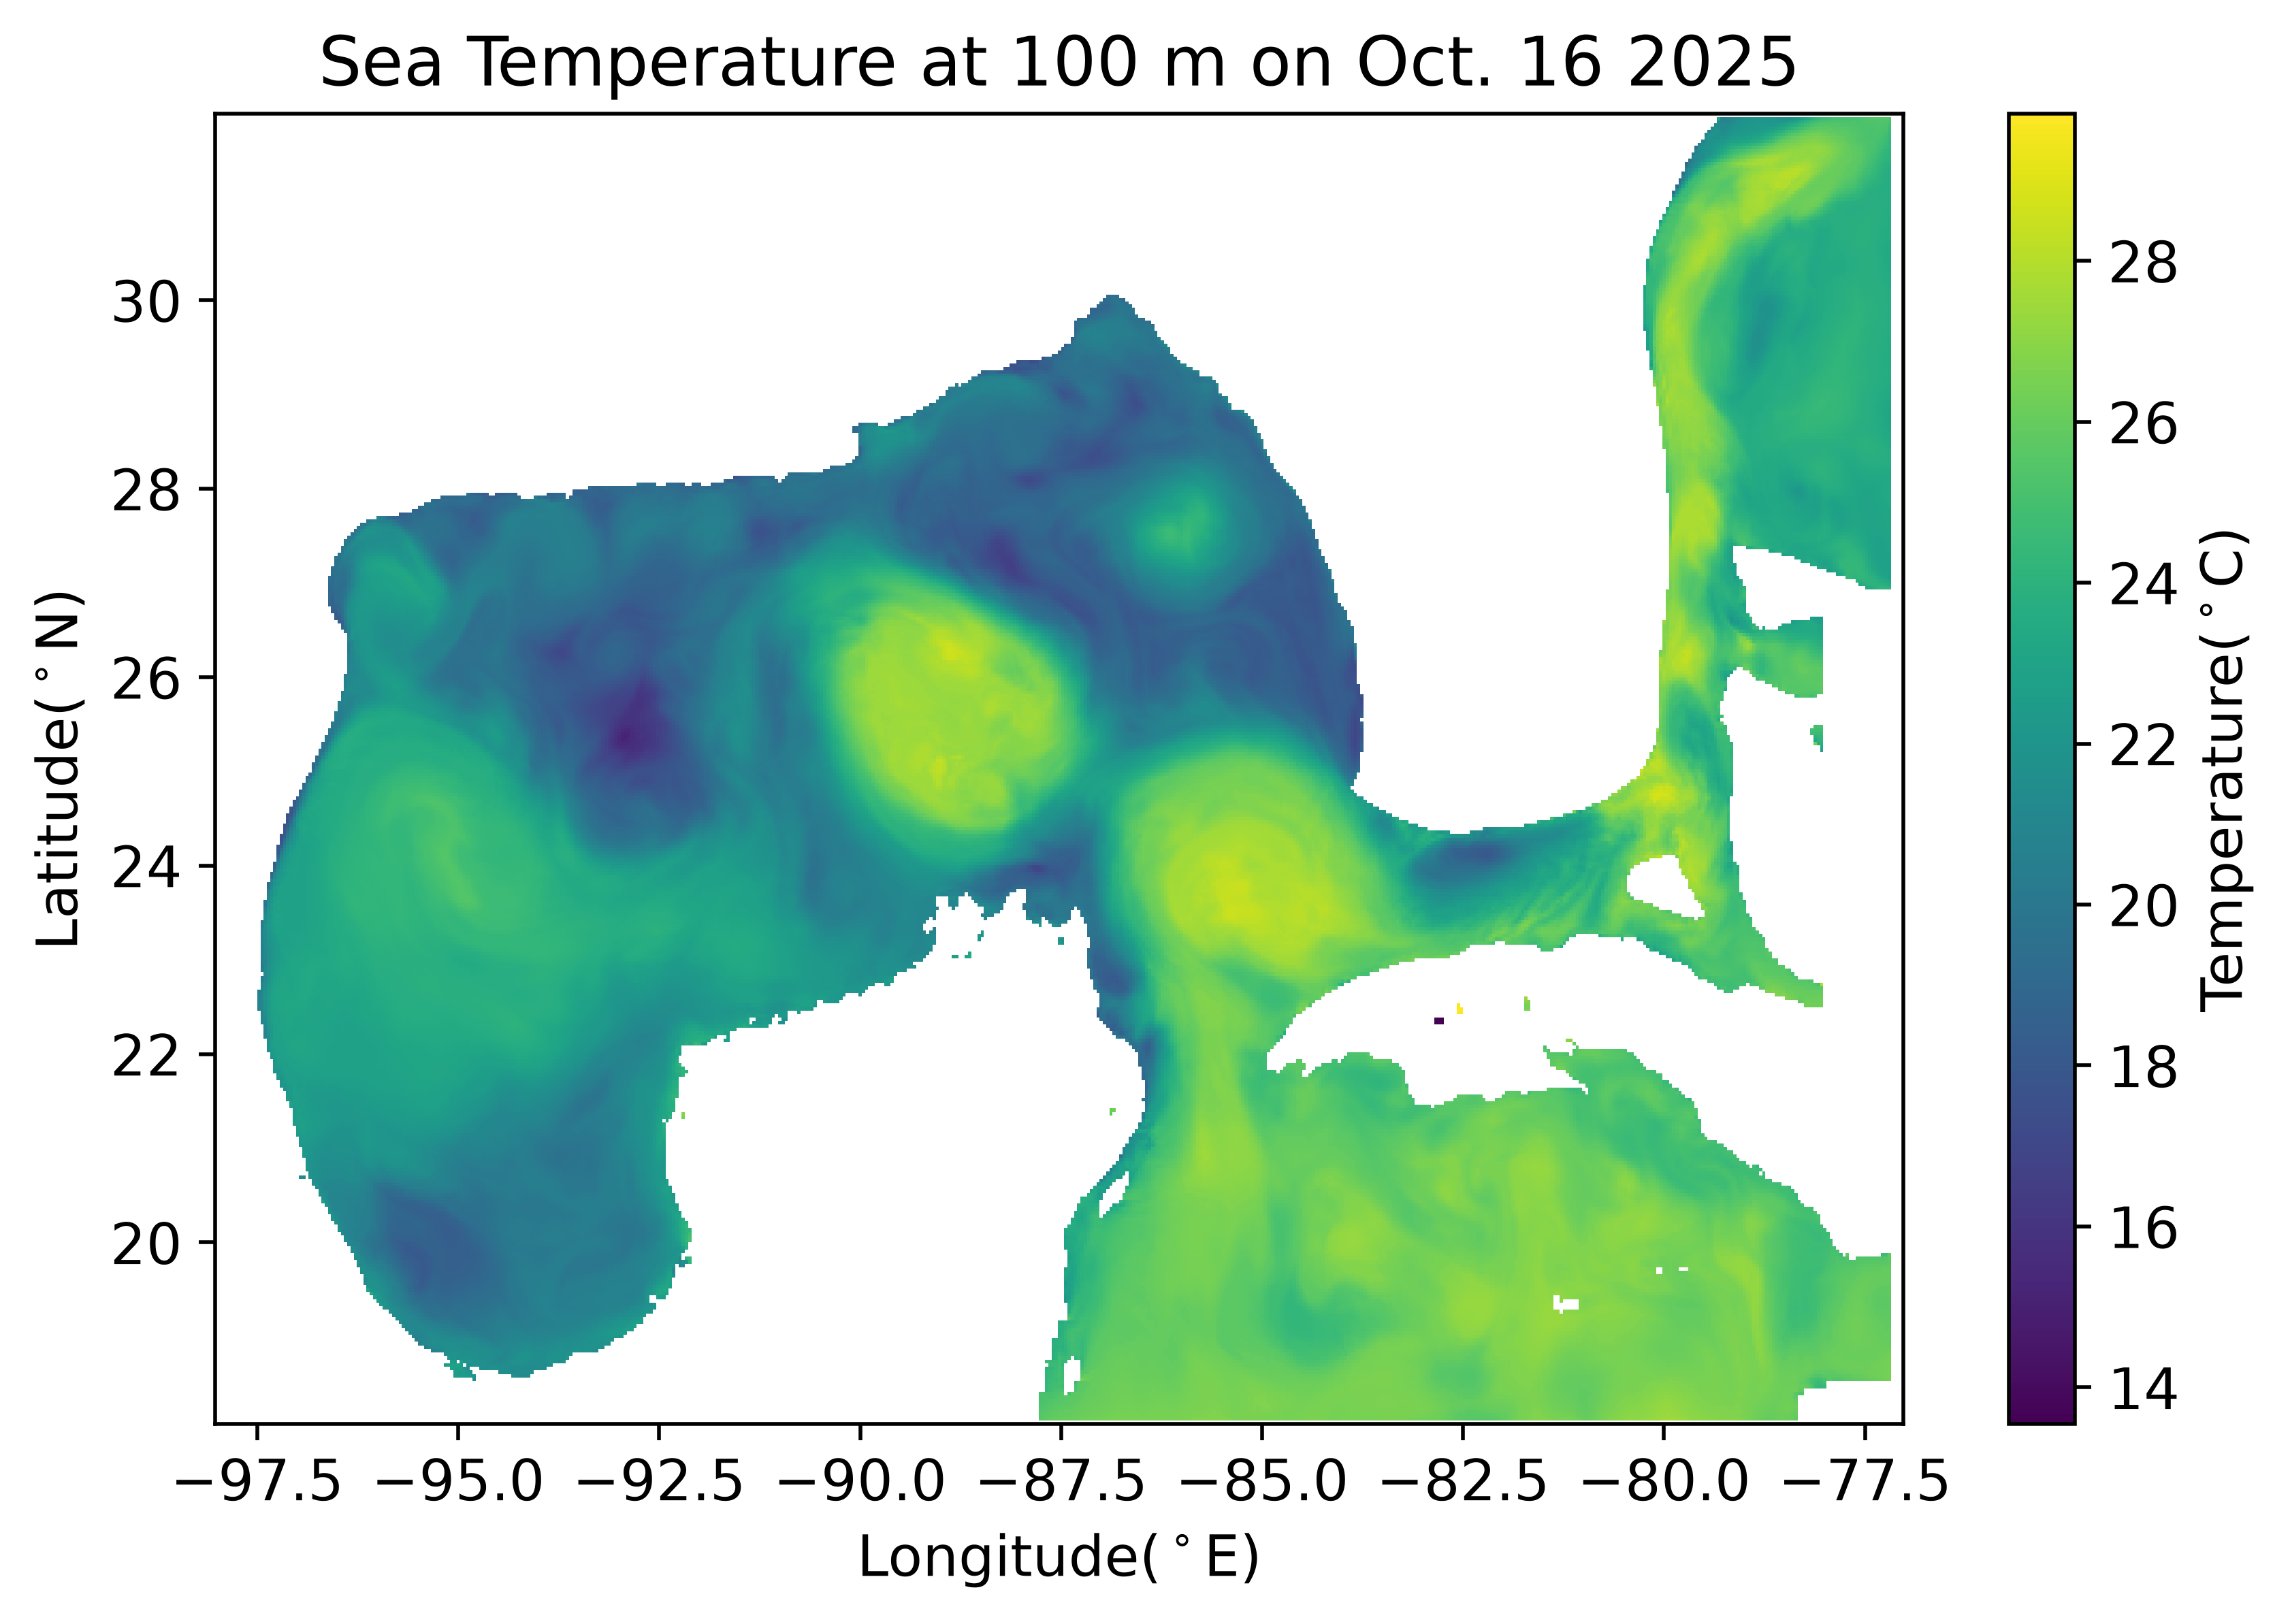

In [16]:
hycom_data_3D.water_temp[0, 19, :, :].plot(cbar_kwargs = {'label': r'Temperature($^\circ$C)'})
plt.title('Sea Temperature at 100 m on Oct. 16 2025')
plt.xlabel(r'Longitude($^\circ$E)')
plt.ylabel(r'Latitude($^\circ$N)')

**E.5** What is the SST for Flower Garden Banks national marine sanctuary on your birthday? Show your work

In [ ]:
# Get index value for 30 m on Oct. 16th 2025
hycom_data_3D.get_index('Depth').get_loc(30.0)

10

In [ ]:
# First going to subset out the water temperature at 30 m depth from the file
wfgb_sst_data = hycom_data_3D.water_temp[0, 10, : , : ]
wfgb_sst_data

<xarray.DataArray 'water_temp' (Latitude: 385, Longitude: 525)> Size: 808kB
[202125 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 2kB 18.09 18.13 18.17 ... 31.89 31.93 31.96
  * Longitude  (Longitude) float32 2kB -98.0 -97.96 -97.92 ... -77.08 -77.04
    MT         float64 8B 4.558e+04
    Date       float64 8B ...
    Depth      float32 4B 30.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.2784758 31.733257 ]
    _ChunkSizes:    [  1  14 193 263]

In [ ]:
# Most western boundary point of West Flower Garden Banks -93.89369. Most easteran boundary is -93.77939
# Northern most boundary is 27.92626. Southern most boundary is 27.81735.
# Subset sst data to include latitude and longitude values that cover the area of the West Flower Garden Banks
wfgb_sst_data_sub = wfgb_sst_data.sel(Longitude = slice(-93.9, -93.7), Latitude = slice(27.8, 28))
wfgb_sst_data_sub

<xarray.DataArray 'water_temp' (Latitude: 6, Longitude: 5)> Size: 120B
[30 values with dtype=float32]
Coordinates:
  * Latitude   (Latitude) float32 24B 27.8 27.84 27.87 27.91 27.94 27.98
  * Longitude  (Longitude) float32 20B -93.88 -93.84 -93.8 -93.76 -93.72
    MT         float64 8B 4.558e+04
    Date       float64 8B ...
    Depth      float32 4B 30.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.2784758 31.733257 ]
    _ChunkSizes:    [  1  14 193 263]

In [68]:
# Use mean() method on subset of water temperature across desired area.
wfgb_sst_data_sub.mean()

<xarray.DataArray 'water_temp' ()> Size: 4B
array(28.406044, dtype=float32)
Coordinates:
    MT       float64 8B 4.558e+04
    Date     float64 8B ...
    Depth    float32 4B 30.0
Attributes:
    long_name:        temp [01.4H]
    standard_name:  sea_water_temperature
    units:          degC
    valid_range:    [ 3.2784758 31.733257 ]
    _ChunkSizes:    [  1  14 193 263]

The average temperature across the West Flower Garden Banks at 30 m depth on October 16th, 2025 was 28.406°C. 